In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train_iter1.parquet')
test = pd.read_parquet('data/test_iter1.parquet')
val = pd.read_parquet('data/val_iter1.parquet')

In [3]:
list(train.columns)

['Attack ID',
 'Attack code_x',
 'Avg source IP count',
 'Start time',
 'End time',
 'Type',
 'Detect count_y',
 'Victim IP_y',
 'Port number_y',
 'Packet speed_y',
 'Data speed_y',
 'Avg packet len_y',
 'Source IP count',
 'Packet speed_y_normalized',
 'Data speed_y_normalized',
 'Avg packet len_y_normalized',
 'total_seconds',
 'weekday_number',
 'time_of_day',
 'IsWeekend',
 'Start Hour',
 'Sin_Hour',
 'Cos_Hour',
 'DayOfYear',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'Mean_DataSpeed',
 'Std_DataSpeed',
 'Min_DataSpeed',
 'Max_DataSpeed',
 'Mean_PacketSpeed',
 'Std_PacketSpeed',
 'Min_PacketSpeed',
 'Max_PacketSpeed',
 'Mean_DetectCount',
 'Std_DetectCount',
 'Min_DetectCount',
 'Max_DetectCount',
 'VictimIP_Count',
 'PortNumber_Count',
 'AvgPacketLen_Mean',
 'AvgPacketLen_Std',
 'DataSpeed_PacketSpeed',
 'PortFrequency',
 'Std_DataSpeed_Replaced',
 'Std_DetectCount_Replaced',
 'AvgPacketLen_Std_Replaced',
 'packet_Total',
 'PacketSpeed_Per_Second',
 'AvgPacketLen_Per_DataSpeed',
 'Data

In [ ]:
x_cols = ['Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y', 
          'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count', 
          'Packet speed_y_normalized', 'Data speed_y_normalized', 'time_of_day',
          'Avg packet len_y_normalized', 'total_seconds', 'weekday_number', 
          'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 
          'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount', 
          'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 
          'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 
          'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 
          'Is_DNS', 'Is_POP3', 'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 
          'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 'Is_TFTP', 'Is_MySQL', 
          'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081', 
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 
          'Is_NTP', 'Is_Kerberos', 'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 
          'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 'Is_BGP', 'Is_IMAPS_Alt', 
          'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 
          'Is_Modbus', 'Is_CoAP', 'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 
          'Is_Elasticsearch', 'Is_Zookeeper', 'Is_Cassandra', 'Is_Docker', 
          'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 'Is_DHCPv6', 
          'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH']

In [5]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()


# Transform 'Attack code_x' column
train['Attack code_x'] = le.fit_transform(train['Attack code_x'])
test['Attack code_x'] = le.fit_transform(test['Attack code_x'])
val['Attack code_x'] = le.fit_transform(val['Attack code_x'])

In [ ]:
smote_cols =['Attack code_x', 'Avg source IP count', 'Detect count_y', 'Victim IP_y', 'Port number_y', 
          'Packet speed_y', 'Data speed_y', 'Avg packet len_y', 'Source IP count', 
          'Packet speed_y_normalized', 'Data speed_y_normalized', 'time_of_day',
          'Avg packet len_y_normalized', 'total_seconds', 'weekday_number', 
          'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 
          'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount', 
          'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 
          'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 
          'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 
          'Is_DNS', 'Is_POP3', 'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 
          'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 'Is_TFTP', 'Is_MySQL', 
          'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081', 
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 
          'Is_NTP', 'Is_Kerberos', 'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 
          'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 'Is_BGP', 'Is_IMAPS_Alt', 
          'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 
          'Is_Modbus', 'Is_CoAP', 'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 
          'Is_Elasticsearch', 'Is_Zookeeper', 'Is_Cassandra', 'Is_Docker', 
          'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 'Is_DHCPv6', 
          'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH']

In [12]:
train['Type'].value_counts()

Type
1    1473625
0     280507
2      65953
Name: count, dtype: int64

In [13]:
from imblearn.over_sampling import SMOTE

# Get the class distribution in the training data
class_counts = train['Type'].value_counts()

# Calculate the desired number of samples for each class
sampling_strategy = {}
majority_class_count = class_counts.max()
for cls, count in class_counts.items():
    if count < majority_class_count:
        sampling_strategy[cls] = int(count * 1.5)  # Double the number of samples for non-majority classes
sampling_strategy

{0: 420760, 2: 98929}

In [14]:
# Initialize SMOTE with the custom sampling strategy
smote = SMOTE(random_state=42, sampling_strategy=sampling_strategy)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(train[smote_cols], train['Type'])

train['Type'].value_counts()

Type
1    1473625
0     280507
2      65953
Name: count, dtype: int64

In [15]:
train = pd.merge(X_train_smote, y_train_smote, left_index=True, right_index=True, how='left')
train['Type'].value_counts()

Type
1    1473625
0     420760
2      98929
Name: count, dtype: int64

In [ ]:
train.to_parquet('data/train.parquet', index=False)

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# Initialize the Random Forest classifier
rfc = RandomForestClassifier(n_estimators=250, random_state=42, max_depth=10, verbose=1)

# Train the classifier on the SMOTE-augmented training data
rfc.fit(X_train_smote[x_cols], y_train_smote)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  3.4min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 14.1min


RandomForestClassifier(max_depth=10, n_estimators=250, random_state=42,
                       verbose=1)

In [18]:
# Predict the labels for the test data
test['pred'] = rfc.predict(test[x_cols])

# Evaluate the model
accuracy = accuracy_score(test['Type'], test['pred'])
print("Accuracy:", accuracy)
precision = precision_score(test['Type'], test['pred'], average='macro')
print("Precision:", precision)
recall = recall_score(test['Type'], test['pred'], average='macro')
print("Recall:", recall)
f1 = f1_score(test['Type'], test['pred'], average='macro')
print("F1-Score:", f1)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    7.4s


Accuracy: 0.817417455458579
Precision: 0.8218888852702438
Recall: 0.5592073875060132
F1-Score: 0.5952891622000803


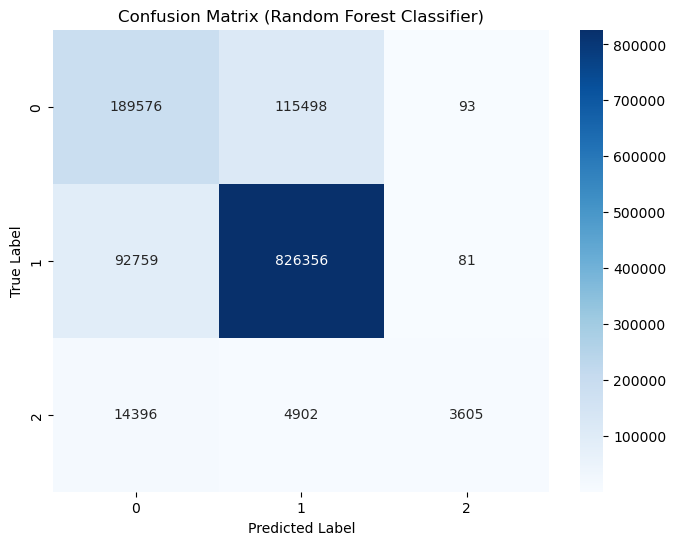

Confusion Matrix (Random Forest Classifier):
 [[189576 115498     93]
 [ 92759 826356     81]
 [ 14396   4902   3605]]


In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 1. Generate the confusion matrix
cm = confusion_matrix(test['Type'], test['pred'])

# 2. Visualize the confusion matrix (optional, but highly recommended)
class_labels = np.unique(test['Type']) # Get unique class labels

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

# 3. Print the confusion matrix (textual representation)
print("Confusion Matrix (Random Forest Classifier):\n", cm)

In [20]:
from sklearn.metrics import classification_report
import numpy as np

# Generate the classification report
report = classification_report(test['pred'], test['Type'])

# Print the classification report
print("Classification Report (Random Forest Classifier):\n", report)

Classification Report (Random Forest Classifier):
               precision    recall  f1-score   support

           0       0.62      0.64      0.63    296731
           1       0.90      0.87      0.89    946756
           2       0.16      0.95      0.27      3779

    accuracy                           0.82   1247266
   macro avg       0.56      0.82      0.60   1247266
weighted avg       0.83      0.82      0.82   1247266



In [ ]:
#RFC
# After SMOTE *2
"""Accuracy: 0.8212698814847835
Precision: 0.6796352669253373
Recall: 0.5641607988228415
F1-Score: 0.5968541729821948"""

# After SMOTE *1.5
"""Accuracy: 0.8317616290350254
Precision: 0.8383765643300584
Recall: 0.5832465366868779
F1-Score: 0.6230823834637998"""

# After SMOTE *1.2
"""Accuracy: 0.8205282594089793
Precision: 0.8171876601009965
Recall: 0.5604558516901181
F1-Score: 0.6038335264459057"""
# After SMOTE *1.7
"""Accuracy: 0.7814820575562871
Precision: 0.5873932085311964
Recall: 0.6415121998728757
F1-Score: 0.599508817810126"""


#GBC
# After SMOTE *2
"""Accuracy: 0.8251615934371658
Precision: 0.7909146881824851
Recall: 0.5628363200435272
F1-Score: 0.6062251027052658"""
# After SMOTE *1.7
"""Accuracy: 0.8326852491769999
Precision: 0.7926796212891074
Recall: 0.5686176500699862
F1-Score: 0.6118089323379017"""
# After SMOTE *1.5
"""Accuracy: 0.8412231232150961
Precision: 0.8303405069778947
Recall: 0.5715682661763412
F1-Score: 0.618068275503768"""
# After SMOTE *1.2
"""Accuracy: 0.8311707366351685
Precision: 0.8163395336379731
Recall: 0.5443079885709823
F1-Score: 0.59572476474654087"""

# ROUND 2
"""Accuracy: 0.8409513287462338
Precision: 0.8295603474049716
Recall: 0.5712815278023611
F1-Score: 0.6176397454337748"""

# ROUND 3
"""Accuracy: 0.8305509811058748
Precision: 0.7800562439370532
Recall: 0.5512748273708772
F1-Score: 0.597186236541299"""


'Accuracy: 0.8409513287462338\nPrecision: 0.8295603474049716\nRecall: 0.5712815278023611\nF1-Score: 0.6176397454337748'